# Customer Attrition Dataset Description

This dataset contains detailed information about bank customers, including demographic details, account information, and behavioral metrics, with a focus on customer attrition. The data is structured as a CSV with various columns that capture customer profiles and their interactions with banking services. The primary goal of this dataset appears to be analyzing factors that contribute to customer retention or attrition, as indicated by the `Attrition_Flag` column.

## Dataset Overview
- **Rows**: The dataset includes multiple customer records (sample shows 65 rows, but the full dataset may contain more).
- **Columns**: 23 columns capturing a mix of categorical, numerical, and predictive features.
- **Date Context**: Analysis is based on data as of March 15, 2025 (current date provided by the system).

## Column Descriptions
1. **CLIENTNUM**: Unique identifier for each customer.
2. **Attrition_Flag**: Indicates customer status (`Existing Customer` or `Attrited Customer`).
3. **Customer_Age**: Age of the customer in years.
4. **Gender**: Customer gender (`M` for male, `F` for female).
5. **Dependent_count**: Number of dependents the customer has.
6. **Education_Level**: Customer's education level (e.g., `High School`, `Graduate`, `Uneducated`, etc.).
7. **Marital_Status**: Marital status of the customer (e.g., `Married`, `Single`, `Divorced`, `Unknown`).
8. **Income_Category**: Annual income range (e.g., `Less than $40K`, `$40K - $60K`, etc.).
9. **Card_Category**: Type of credit card held (e.g., `Blue`, `Silver`, `Gold`).
10. **Months_on_book**: Duration of the customer relationship with the bank in months.
11. **Total_Relationship_Count**: Number of products/services the customer uses.
12. **Months_Inactive_12_mon**: Number of months inactive in the last 12 months.
13. **Contacts_Count_12_mon**: Number of contacts with the bank in the last 12 months.
14. **Credit_Limit**: Customer's credit limit.
15. **Total_Revolving_Bal**: Total revolving balance on the credit card.
16. **Avg_Open_To_Buy**: Average open-to-buy credit line (credit limit minus revolving balance).
17. **Total_Amt_Chng_Q4_Q1**: Change in transaction amount from Q4 to Q1.
18. **Total_Trans_Amt**: Total transaction amount over a period.
19. **Total_Trans_Ct**: Total transaction count over a period.
20. **Total_Ct_Chng_Q4_Q1**: Change in transaction count from Q4 to Q1.
21. **Avg_Utilization_Ratio**: Average credit utilization ratio (revolving balance divided by credit limit).
22. **Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1**: Probability of being an existing customer (based on a Naive Bayes classifier).
23. **Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2**: Probability of being an attrited customer (based on a Naive Bayes classifier).

## Potential Use Cases
- **Attrition Analysis**: Identify patterns or predictors of customer churn.
- **Customer Segmentation**: Group customers based on demographics, income, or behavior.
- **Credit Risk Assessment**: Evaluate credit utilization and transaction trends.
- **Predictive Modeling**: Use the Naive Bayes probabilities or build new models to predict attrition.

This dataset provides a rich foundation for exploratory data analysis (EDA), statistical modeling, and machine learning applications aimed at understanding customer behavior and improving retention strategies.

--- 



# Initial Data Loading and Exploration

This section covers the initial steps of loading the customer attrition dataset into a pandas DataFrame and performing basic exploratory analysis. The code imports necessary libraries, loads the data, displays a styled preview, checks the dataset's shape and structure, and prepares the data by dropping specific columns.

## Objectives
- Load the dataset and verify its structure.
- Display the first few rows with custom styling for better readability.
- Assess the dataset's dimensions and data types.
- Remove unnecessary columns (e.g., `CLIENTNUM` and the last two Naive Bayes classifier columns) to simplify further analysis.

## Steps
1. **Library Imports**: Import essential Python libraries for data manipulation, visualization, and machine learning.
2. **Data Loading**: Load the dataset from a CSV file into a DataFrame.
3. **Preview**: Show the first 5 rows with a styled format.
4. **Shape and Info**: Check the dataset's size and column details.
5. **Column Dropping**: Remove the `CLIENTNUM` column and the last two columns to focus on core features.

In [56]:
# Pandas for data manipulation
import pandas as pd

# NumPy for numerical operations
import numpy as np

# Matplotlib for basic plots
import matplotlib.pyplot as plt

# Seaborn for statistical plots
import seaborn as sns

# Plotly for interactive plots
import plotly.express as px

# Scikit-learn for ML tasks
from sklearn.model_selection import train_test_split  # Split data
from sklearn.preprocessing import StandardScaler  # Scale features
from sklearn.linear_model import LogisticRegression  # Logistic regression
from sklearn.naive_bayes import GaussianNB  # Naive Bayes
from sklearn.metrics import accuracy_score  # Model accuracy


from imblearn.over_sampling import SMOTE
from PIL import Image
import os


## skelarn -- preprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn_features.transformers import DataFrameSelector



## skelarn -- models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

## sklearn -- metrics
from sklearn.metrics import f1_score, confusion_matrix





In [4]:
# Load dataset into DataFrame
df = pd.read_csv("dataset.csv")

In [5]:
df.head().style.set_properties(
    **{
        "background-color": "black",
        "color": "white",
        "border-color": "black",
        "font-size": "11.5pt",
        "width": 200,
    }
)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.000000,777,11914.000000,1.335000,1144,42,1.625000,0.061000,0.000093,0.999910
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.000000,864,7392.000000,1.541000,1291,33,3.714000,0.105000,0.000057,0.999940
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.000000,0,3418.000000,2.594000,1887,20,2.333000,0.000000,0.000021,0.999980
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.000000,2517,796.000000,1.405000,1171,20,2.333000,0.760000,0.000134,0.999870
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.000000,0,4716.000000,2.175000,816,28,2.500000,0.000000,0.000022,0.999980


In [6]:
# The shape of the dataset..
df.shape

(10127, 23)

In [7]:
# Display DataFrame info...
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [8]:
# Dropping the last two columns and the client number column
df = df.iloc[:,1:-2]

In [9]:
#The dimensions of the dataset.......
df.ndim

2

In [10]:
# Display DataFrame info...
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  object 
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  object 
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  object 
 5   Marital_Status            10127 non-null  object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

# Data Quality Check and Preprocessing

This section focuses on assessing the quality of the customer attrition dataset and performing initial preprocessing steps. The code checks for missing values and duplicates, provides statistical summaries of numerical and categorical columns, samples random rows for inspection, and converts the `Attrition_Flag` column into a binary format for modeling.

## Objectives
- Ensure data completeness by identifying missing values and duplicates.
- Summarize key statistics for numerical and categorical features.
- Preview a random sample of the dataset.
- Transform the target variable (`Attrition_Flag`) into a numerical format suitable for machine learning.

## Steps
1. **Check NaN Values**: Count missing values in each column using `isnull().sum()`.
2. **Check Duplicates**: Count duplicate rows with `duplicated().sum()`.
3. **Numerical Summary**: Generate and round statistics for numerical columns (excluding categorical ones).
4. **Categorical Summary**: Summarize categorical columns (excluding numerical types) with rounded counts.
5. **Transform Attrition_Flag**: Map `Existing Customer` to 0 and `Attrited Customer` to 1 for binary classification.

In [11]:
# Checking NAN Values
df.isnull().sum()

Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [12]:
# Checking duplicates
df.duplicated().sum()

0

In [13]:
# Summarize numerical columns, excluding objects, rounded to 2
round(df.describe(exclude="object"), 2)

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00
mean,46.33,2.35,35.93,3.81,2.34,2.46,8631.95,1162.81,7469.14,0.76,4404.09,64.86,0.71,0.27
std,8.02,1.30,7.99,1.55,1.01,1.11,9088.78,814.99,9090.69,0.22,3397.13,23.47,0.24,0.28
min,26.00,0.00,13.00,1.00,0.00,0.00,1438.30,0.00,3.00,0.00,510.00,10.00,0.00,0.00
25%,41.00,1.00,31.00,3.00,2.00,2.00,2555.00,359.00,1324.50,0.63,2155.50,45.00,0.58,0.02
50%,46.00,2.00,36.00,4.00,2.00,2.00,4549.00,1276.00,3474.00,0.74,3899.00,67.00,0.70,0.18
75%,52.00,3.00,40.00,5.00,3.00,3.00,11067.50,1784.00,9859.00,0.86,4741.00,81.00,0.82,0.50
max,73.00,5.00,56.00,6.00,6.00,6.00,34516.00,2517.00,34516.00,3.40,18484.00,139.00,3.71,1.00


In [14]:
# Summarize categorical columns, excluding float and int64 types, rounded to 2
round(df.describe(exclude=["float", "int64"]), 2)

,Attrition_Flag,Gender,Education_Level,Marital_Status,Income_Category,Card_Category
count,10127,10127,10127,10127,10127,10127
unique,2,2,7,4,6,4
top,Existing Customer,F,Graduate,Married,Less than $40K,Blue
freq,8500,5358,3128,4687,3561,9436


In [15]:
df.sample(5)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
7256,Existing Customer,54,F,2,Unknown,Single,Less than $40K,Blue,46,3,2,3,4170.0,641,3529.0,0.815,3669,67,0.595,0.154
5170,Existing Customer,60,F,0,Graduate,Unknown,Less than $40K,Blue,36,4,3,1,3828.0,0,3828.0,0.599,4470,58,0.812,0.000
6157,Existing Customer,47,F,2,Unknown,Single,Less than $40K,Blue,41,5,3,1,2289.0,1611,678.0,0.648,4817,77,0.750,0.704
3969,Existing Customer,38,M,3,Graduate,Single,$40K - $60K,Blue,31,3,1,3,5362.0,1110,4252.0,0.651,3548,69,0.500,0.207
1766,Existing Customer,56,M,2,Graduate,Married,$120K +,Blue,49,4,1,4,8902.0,1932,6970.0,0.781,969,29,1.071,0.217


In [16]:
# Changing the Attrition_Flag to 0 and 1 
df["Attrition_Flag"] = df["Attrition_Flag"].map({"Existing Customer":0, "Attrited Customer":1})

In [17]:
df.sample(5)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
3724,0,42,F,4,College,Single,Unknown,Blue,34,5,3,2,15449.0,0,15449.0,0.783,4098,81,0.588,0.000
1291,0,38,F,2,Uneducated,Single,Less than $40K,Blue,29,3,3,2,3590.0,1924,1666.0,0.573,1472,37,0.762,0.536
1653,0,54,M,3,College,Married,$80K - $120K,Blue,45,4,3,0,3380.0,1655,1725.0,0.636,1636,58,0.706,0.490
1031,0,45,M,2,Graduate,Divorced,$40K - $60K,Blue,40,3,3,2,2259.0,954,1305.0,0.695,1393,35,0.842,0.422
6388,1,41,M,2,High School,Married,$120K +,Blue,24,5,2,3,9924.0,0,9924.0,0.517,1949,43,0.483,0.000


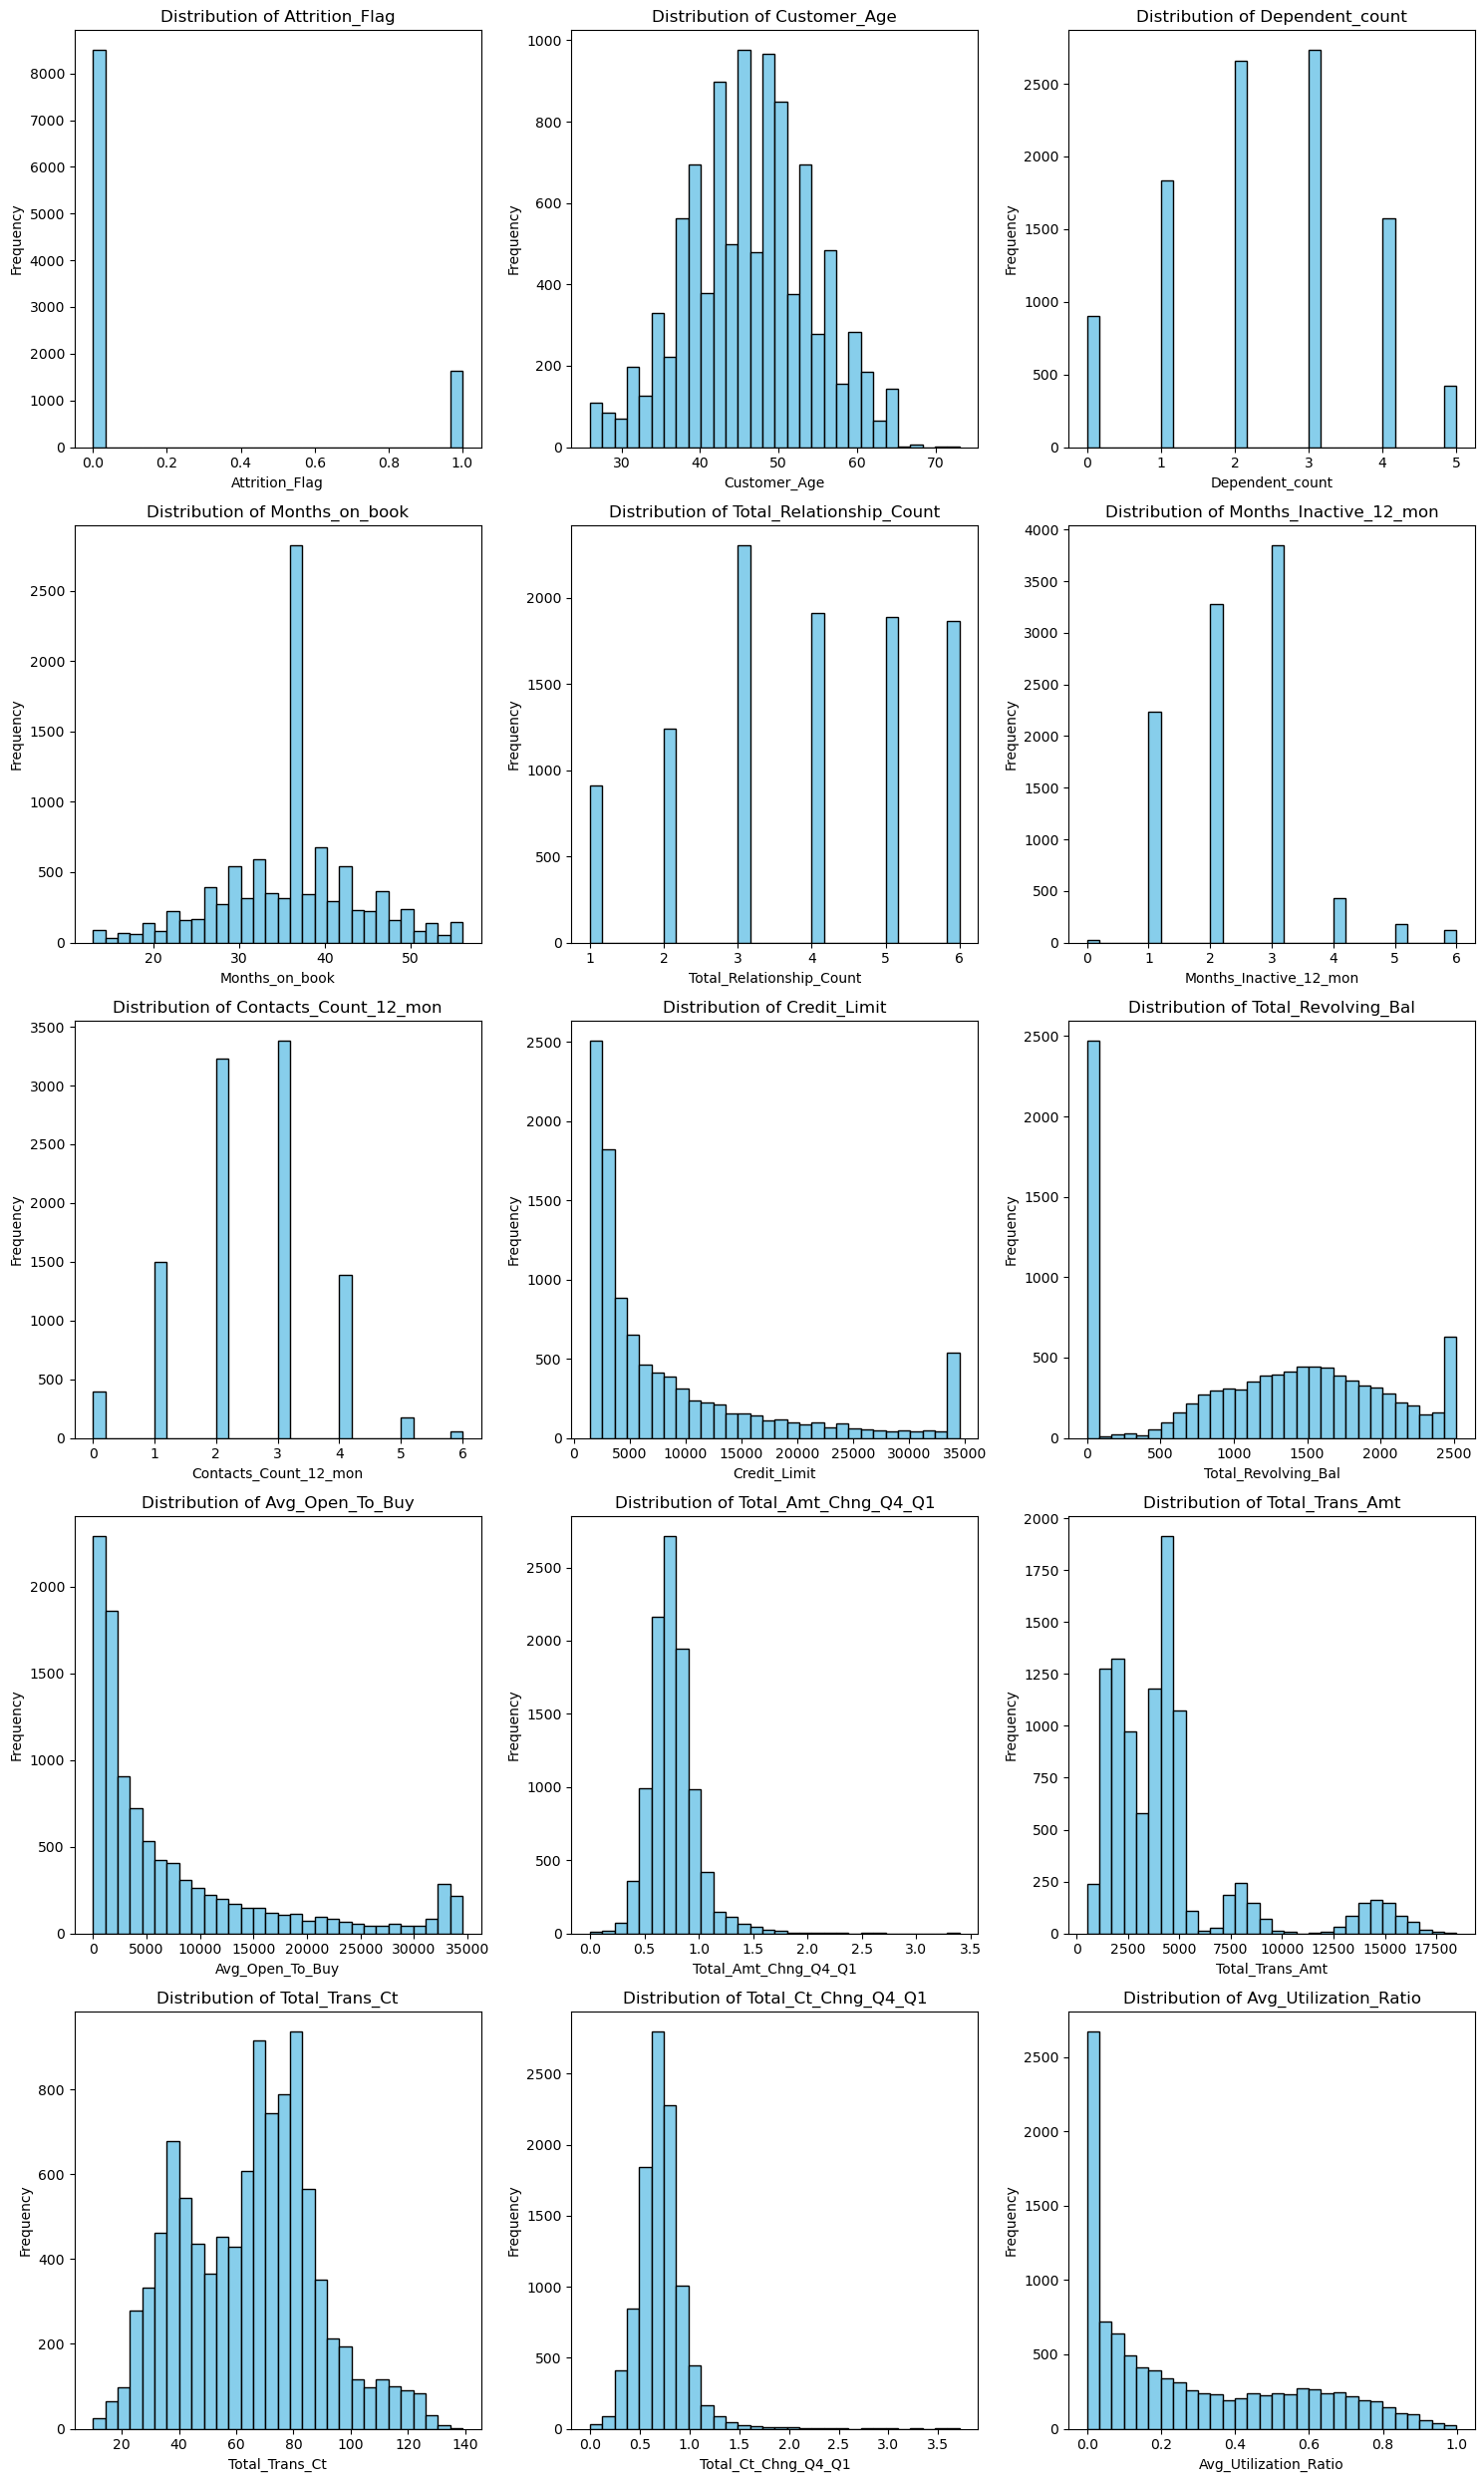

In [18]:
# Select numerical columns (int64 and float64)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Set up the figure and axes for subplots
n_cols = 3  # Number of columns in the subplot grid
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols  # Calculate rows needed
plt.figure(figsize=(15, 5 * n_rows))  # Adjust figure size based on number of plots

# Create histograms for each numerical column
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

# Adjust layout and display
plt.tight_layout()
plt.show()

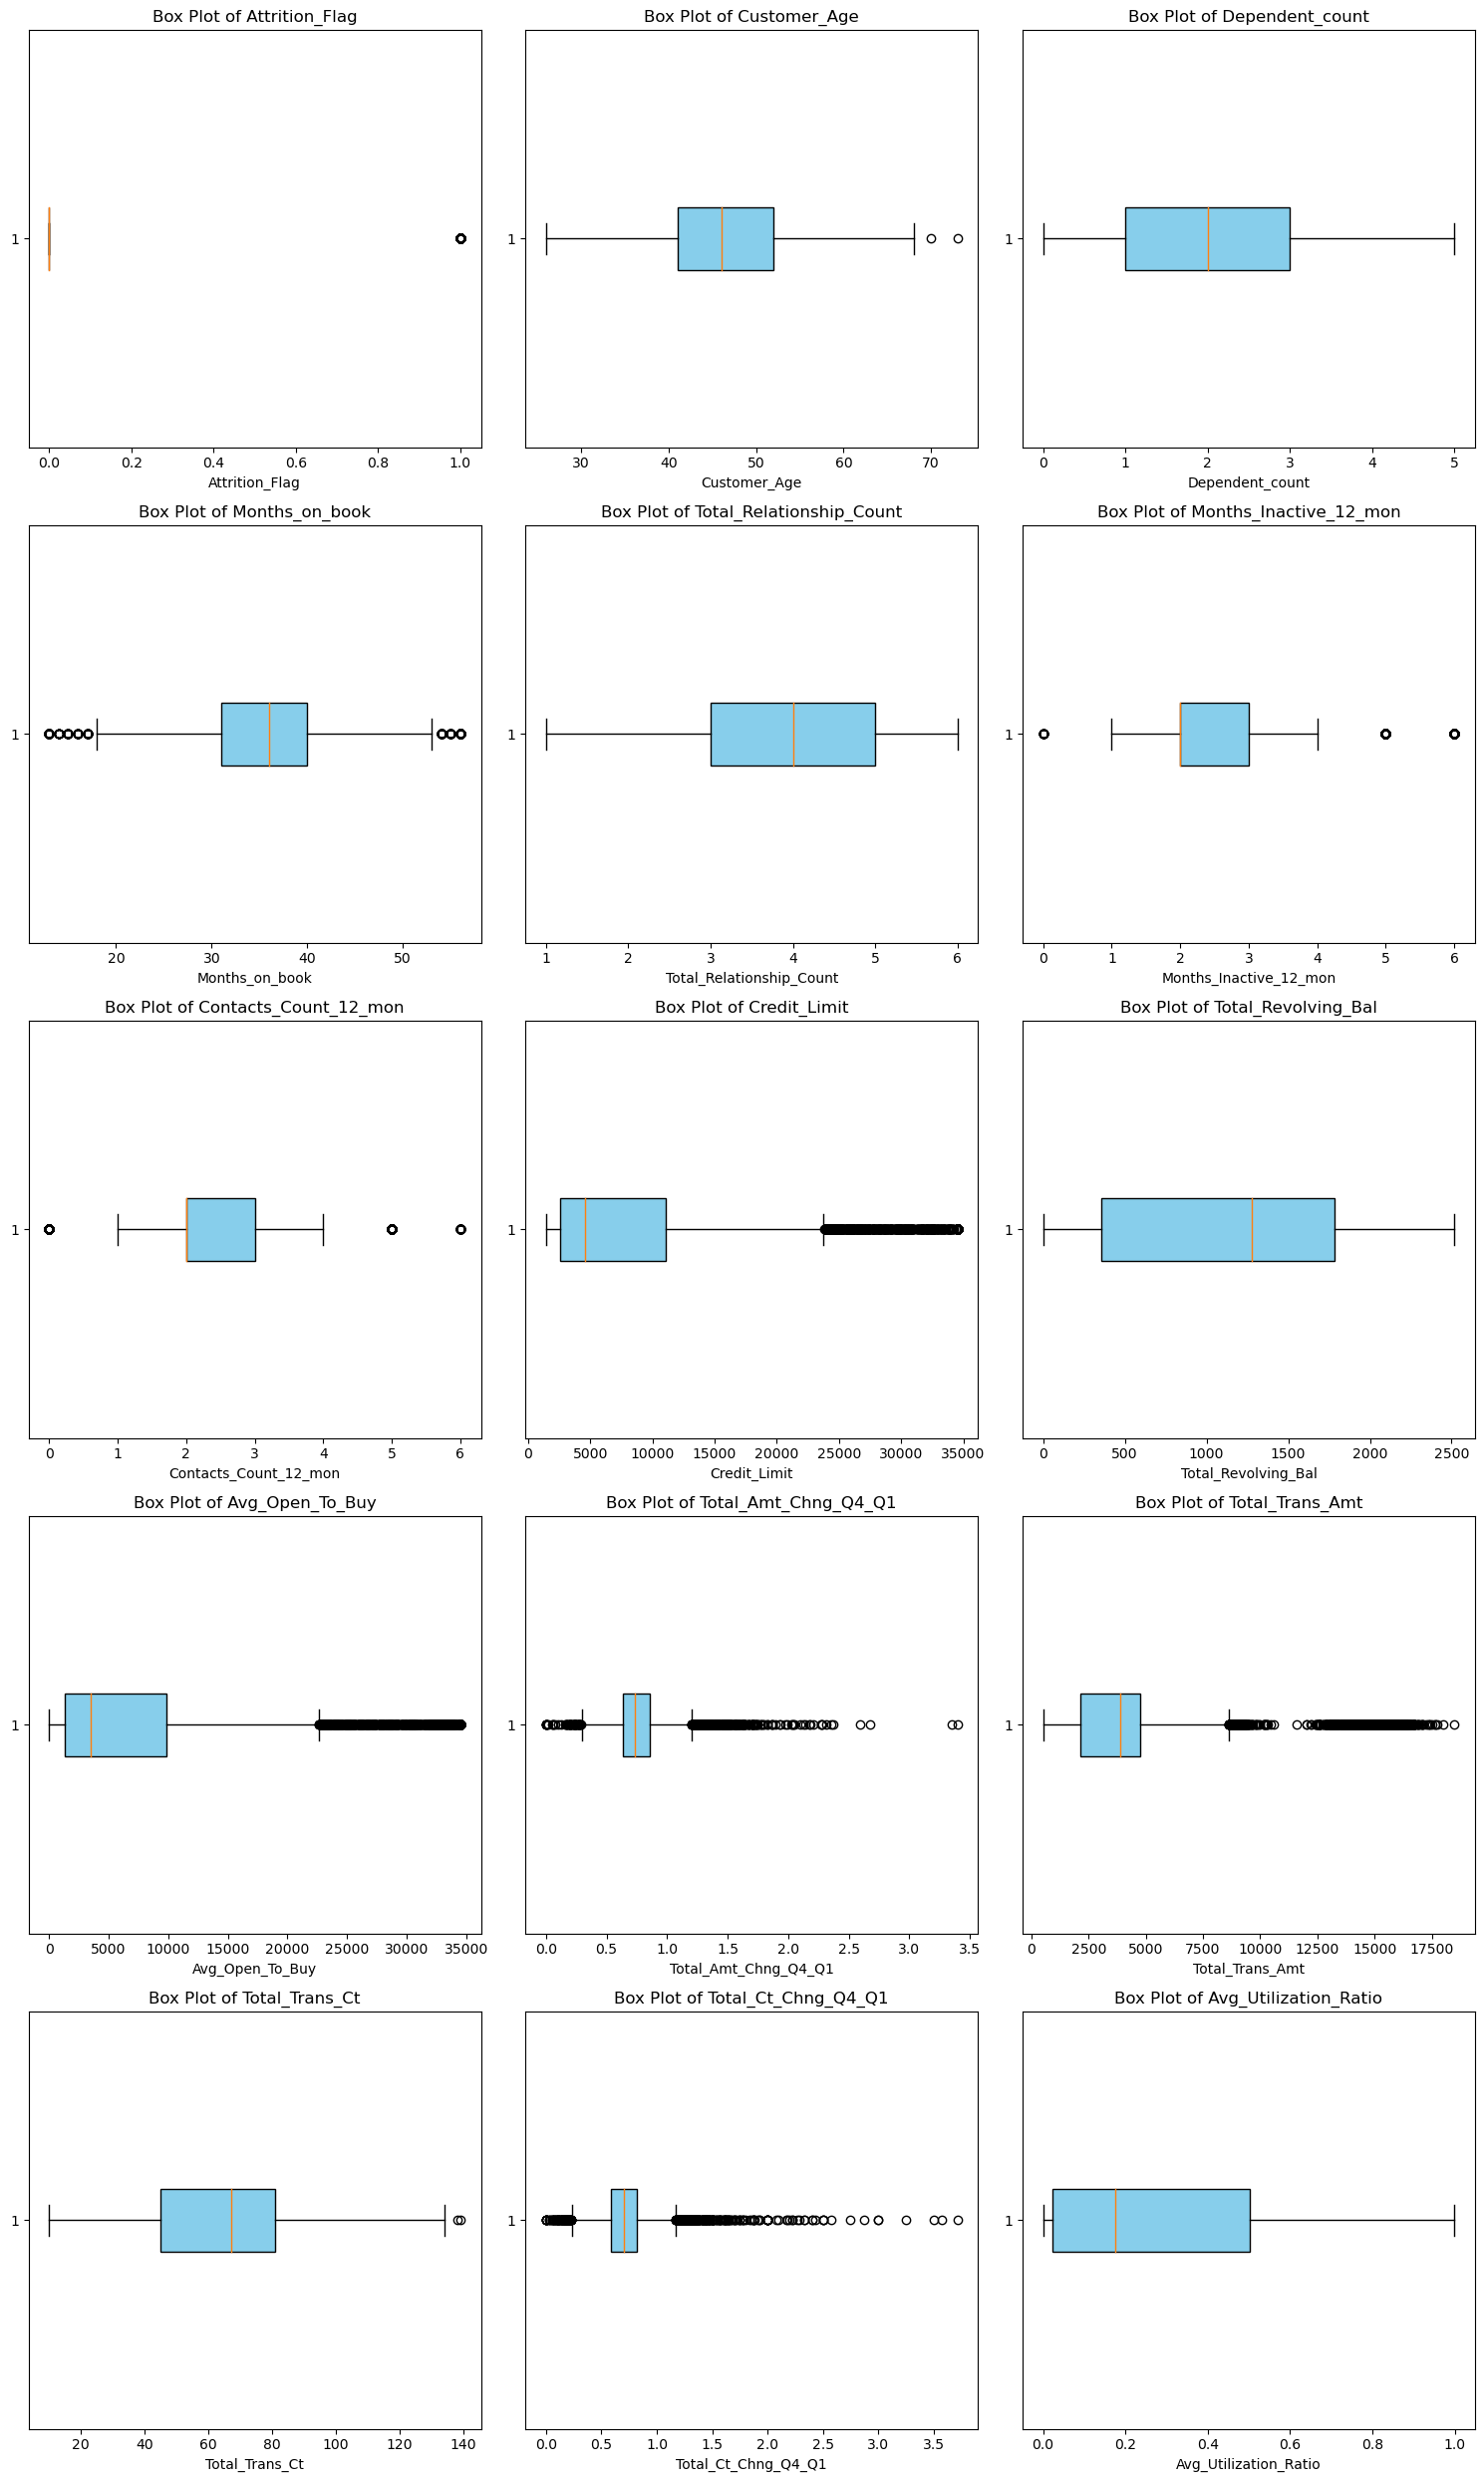

In [19]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Function to detect outliers using IQR
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)  # First quartile
    Q3 = df[column].quantile(0.75)  # Third quartile
    IQR = Q3 - Q1  # Interquartile range
    lower_bound = Q1 - 1.5 * IQR  # Lower outlier threshold
    upper_bound = Q3 + 1.5 * IQR  # Upper outlier threshold
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    return outliers


# Visualize outliers with box plots
n_cols = 3  # Number of columns in subplot grid
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols  # Calculate rows needed
plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(df[col], vert=False, patch_artist=True, boxprops=dict(facecolor='skyblue'))
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

In [20]:
# Handle Problem With Customer_Age

df["Age"] = 0
df.loc[(df["Customer_Age"] > 25) & (df["Customer_Age"] <= 35), "Age"] = 0
df.loc[(df["Customer_Age"] > 35) & (df["Customer_Age"] <= 45), "Age"] = 1
df.loc[(df["Customer_Age"] > 45) & (df["Customer_Age"] <= 55), "Age"] = 2
df.loc[df["Customer_Age"] > 55, "Age"] = 3
df["Age"] = df["Age"].astype(int)

In [21]:
# Drop the "Customer_Age" column from the DataFrame
df.drop(['Customer_Age'], axis=1, inplace=True)


In [22]:
# Count occurrences of each unique value in the "Age" column
df["Age"].value_counts()

2    4135
1    3742
3    1331
0     919
Name: Age, dtype: int64

In [23]:
# Initialize "Bank_Relationship_Period" column with default value 0

df["Bank_Relationship_Period"] = 0


# Categorize customers based on "Months_on_book"
df.loc[
    (df["Months_on_book"] >= 0) & (df["Months_on_book"] <= 10),
    "Bank_Relationship_Period",
] = 0
df.loc[
    (df["Months_on_book"] > 10) & (df["Months_on_book"] <= 20),
    "Bank_Relationship_Period",
] = 1
df.loc[
    (df["Months_on_book"] > 20) & (df["Months_on_book"] <= 30),
    "Bank_Relationship_Period",
] = 2
df.loc[
    (df["Months_on_book"] > 30) & (df["Months_on_book"] <= 40),
    "Bank_Relationship_Period",
] = 3
df.loc[df["Months_on_book"] > 50, "Bank_Relationship_Period"] = 4



In [24]:
# Convert "Bank_Relationship_Period" column to integer type
df["Bank_Relationship_Period"] = df["Bank_Relationship_Period"].astype(int)

In [25]:
# Drop the "Months_on_book" column from the DataFrame
df.drop(['Months_on_book'], axis=1, inplace=True)


In [26]:
df.sample(10)

,Attrition_Flag,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Age,Bank_Relationship_Period
8938,0,M,1,High School,Unknown,$80K - $120K,Blue,1,2,2,26840.0,769,26071.0,0.609,7969,93,0.661,0.029,2,3
3953,0,M,3,High School,Single,$60K - $80K,Blue,6,2,4,11550.0,1505,10045.0,1.034,3891,76,0.900,0.130,1,2
1710,0,F,3,Unknown,Married,Less than $40K,Blue,6,3,2,2280.0,1170,1110.0,0.603,1924,50,0.667,0.513,2,0
6489,0,M,3,Post-Graduate,Single,$80K - $120K,Blue,5,2,3,19724.0,0,19724.0,0.644,3830,82,0.673,0.000,1,3
6665,0,F,1,Graduate,Single,Unknown,Blue,3,1,1,2884.0,2517,367.0,0.693,4809,87,0.740,0.873,1,3
3387,0,F,2,Unknown,Single,Less than $40K,Blue,6,3,3,1438.3,0,1438.3,0.683,2598,59,0.595,0.000,1,2
2430,0,F,1,Uneducated,Married,$40K - $60K,Blue,6,3,3,2151.0,1338,813.0,0.926,3446,58,1.000,0.622,2,0
6157,0,F,2,Unknown,Single,Less than $40K,Blue,5,3,1,2289.0,1611,678.0,0.648,4817,77,0.750,0.704,2,0
8307,0,F,1,Unknown,Single,Less than $40K,Blue,2,2,1,2029.0,1074,955.0,0.514,4802,90,0.800,0.529,2,3
2748,0,F,0,Graduate,Married,Less than $40K,Blue,6,3,4,2107.0,1351,756.0,0.521,1320,35,0.522,0.641,3,3


In [27]:
import plotly.express as px

# Count the occurrences of each category in "Attrition_Flag"
attrition_counts = df['Attrition_Flag'].value_counts().reset_index()
attrition_counts.columns = ['Attrition_Flag', 'Count']

# Create an interactive pie chart with a different color scheme
fig = px.pie(attrition_counts, values='Count', names='Attrition_Flag', 
             title='Attrition Flag Distribution', 
             color_discrete_sequence=px.colors.sequential.Blugrn_r)  # Change color scheme

# Remove background
fig.update_layout(
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    title_font=dict(size=18, color='skyblue', family="Arial") 
)

# Show the figure
fig.show()


In [28]:
df['Age'].value_counts()

2    4135
1    3742
3    1331
0     919
Name: Age, dtype: int64

In [29]:
# Count occurrences of each "Bank_Relationship_Period" grouped by "Attrition_Flag"
attrition_counts = (
    df.groupby("Age")["Attrition_Flag"]
    .value_counts()
    .unstack()
    .reset_index()
)

# Melt the DataFrame for proper formatting
attrition_counts = attrition_counts.melt(
    id_vars=["Age"], var_name="Attrition_Flag", value_name="Count"
)

# Create a bar plot
fig = px.bar(
    attrition_counts,
    x="Age",
    y="Count",
    color="Attrition_Flag",
    title="Attrition Flag by Age",
    color_discrete_sequence=px.colors.qualitative.Bold,
)  # Custom color palette

# Customize layout (remove background, change title color)
fig.update_layout(
    paper_bgcolor="rgba(0,0,0,0)",  # Transparent background
    plot_bgcolor="rgba(0,0,0,0)",
    title_font=dict(size=18, color="Skyblue", family="Arial"),  # Custom title color

    xaxis=dict(
        title='Age',
        title_font=dict(size=14, color='skyblue'),  # X-axis label color
        tickfont=dict(size=12, color='skyblue')  # X-axis numbers color
    ),
    yaxis=dict(
        title='Count',
        title_font=dict(size=14, color='skyblue'),  # Y-axis label color
        tickfont=dict(size=12, color='skyblue')  # Y-axis numbers color
    ),
    barmode="group",  # Group bars side by side
)

# Show the figure
fig.show()

In [30]:
df['Dependent_count'].value_counts()

3    2732
2    2655
1    1838
4    1574
0     904
5     424
Name: Dependent_count, dtype: int64

In [31]:
# Count occurrences of each "Bank_Relationship_Period" grouped by "Attrition_Flag"
attrition_counts = (
    df.groupby("Dependent_count")["Attrition_Flag"]
    .value_counts()
    .unstack()
    .reset_index()
)

# Melt the DataFrame for proper formatting
attrition_counts = attrition_counts.melt(
    id_vars=["Dependent_count"], var_name="Attrition_Flag", value_name="Count"
)

# Create a bar plot
fig = px.bar(
    attrition_counts,
    x="Dependent_count",
    y="Count",
    color="Attrition_Flag",
    title="Attrition Flag by Dependent_count",
    color_discrete_sequence=px.colors.qualitative.Bold,
)  # Custom color palette

# Customize layout (remove background, change title color)
fig.update_layout(
    paper_bgcolor="rgba(0,0,0,0)",  # Transparent background
    plot_bgcolor="rgba(0,0,0,0)",
    title_font=dict(size=18, color="Skyblue", family="Arial"),  # Custom title color

    xaxis=dict(
        title='Dependent_count',
        title_font=dict(size=14, color='skyblue'),  # X-axis label color
        tickfont=dict(size=12, color='skyblue')  # X-axis numbers color
    ),
    yaxis=dict(
        title='Count',
        title_font=dict(size=14, color='skyblue'),  # Y-axis label color
        tickfont=dict(size=12, color='skyblue')  # Y-axis numbers color
    ),
    barmode="group",  # Group bars side by side
)

# Show the figure
fig.show()

In [32]:
df['Total_Relationship_Count'].value_counts()

3    2305
4    1912
5    1891
6    1866
2    1243
1     910
Name: Total_Relationship_Count, dtype: int64

In [33]:
# Count occurrences of each "Bank_Relationship_Period" grouped by "Attrition_Flag"
attrition_counts = (
    df.groupby("Bank_Relationship_Period")["Attrition_Flag"]
    .value_counts()
    .unstack()
    .reset_index()
)

# Melt the DataFrame for proper formatting
attrition_counts = attrition_counts.melt(
    id_vars=["Bank_Relationship_Period"], var_name="Attrition_Flag", value_name="Count"
)

# Create a bar plot
fig = px.bar(
    attrition_counts,
    x="Bank_Relationship_Period",
    y="Count",
    color="Attrition_Flag",
    title="Attrition Flag by Bank Relationship Period",
    color_discrete_sequence=px.colors.qualitative.Bold,
)  # Custom color palette

# Customize layout (remove background, change title color)
fig.update_layout(
    paper_bgcolor="rgba(0,0,0,0)",  # Transparent background
    plot_bgcolor="rgba(0,0,0,0)",
    title_font=dict(size=18, color="Skyblue", family="Arial"),  # Custom title color

    xaxis=dict(
        title='Bank Relationship Period',
        title_font=dict(size=14, color='skyblue'),  # X-axis label color
        tickfont=dict(size=12, color='skyblue')  # X-axis numbers color
    ),
    yaxis=dict(
        title='Count',
        title_font=dict(size=14, color='skyblue'),  # Y-axis label color
        tickfont=dict(size=12, color='skyblue')  # Y-axis numbers color
    ),
    barmode="group",  # Group bars side by side
)

# Show the figure
fig.show()

In [34]:
fig = px.bar(df.groupby(['Bank_Relationship_Period', 'Age'])['Attrition_Flag'].value_counts().reset_index(name='Count'),
             x='Bank_Relationship_Period', 
             y='Count', 
             color='Attrition_Flag', 
             facet_col='Age', 
             title='Grouped Bar Chart: Attrition by Bank Relationship Period & Age',
             barmode='group')

fig.show()


In [35]:
df.sample(6)

,Attrition_Flag,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Age,Bank_Relationship_Period
2392,0,M,4,Graduate,Married,$60K - $80K,Blue,3,2,2,14607.0,1480,13127.0,0.346,1393,38,0.462,0.101,3,3
86,0,M,2,High School,Single,$120K +,Blue,4,2,1,19040.0,2056,16984.0,0.607,1212,31,0.722,0.108,2,3
7496,0,M,1,Unknown,Single,Unknown,Blue,5,1,1,18457.0,2248,16209.0,0.578,3603,69,0.643,0.122,3,3
9642,0,M,2,College,Married,Less than $40K,Blue,3,3,2,8848.0,961,7887.0,0.884,15352,117,0.671,0.109,1,1
5504,0,M,1,College,Single,$40K - $60K,Blue,3,1,1,2800.0,1338,1462.0,0.818,4869,90,0.800,0.478,2,0
2532,0,M,1,Unknown,Unknown,$80K - $120K,Blue,6,1,4,2797.0,1802,995.0,0.675,3525,63,0.750,0.644,2,2


In [36]:
fig = px.bar(df.groupby(['Bank_Relationship_Period','Total_Relationship_Count'])['Attrition_Flag'].value_counts().reset_index(name='Count'),
             x='Total_Relationship_Count', 
             y='Count', 
             color='Attrition_Flag', 
             facet_col='Bank_Relationship_Period', 
             title='Grouped Bar Chart: Attrition by Bank_Relationship_Period & Total_Relationship_Count',
             barmode='group')

fig.show()


In [37]:
fig = px.scatter(df, 
                 x='Total_Trans_Ct', 
                 y='Total_Trans_Amt', 
                 color='Attrition_Flag',
                 title='Scatter Plot: Total_Trans_Amt vs. AgTotal_Trans_Cte',
                 size_max=20, 
                 opacity=1, 
                 color_discrete_sequence=px.colors.qualitative.Set2)

fig.show()


In [38]:
fig = px.scatter(df, 
                 x='Total_Ct_Chng_Q4_Q1', 
                 y='Total_Trans_Amt', 
                 color='Attrition_Flag',
                 title='Scatter Plot: Total_Trans_Amt vs. Total_Ct_Chng_Q4_Q1',
                 size_max=20, 
                 opacity=1, 
                 color_discrete_sequence=px.colors.qualitative.Set2)

fig.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_1756\3333785325.py:1: FutureWarning:

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



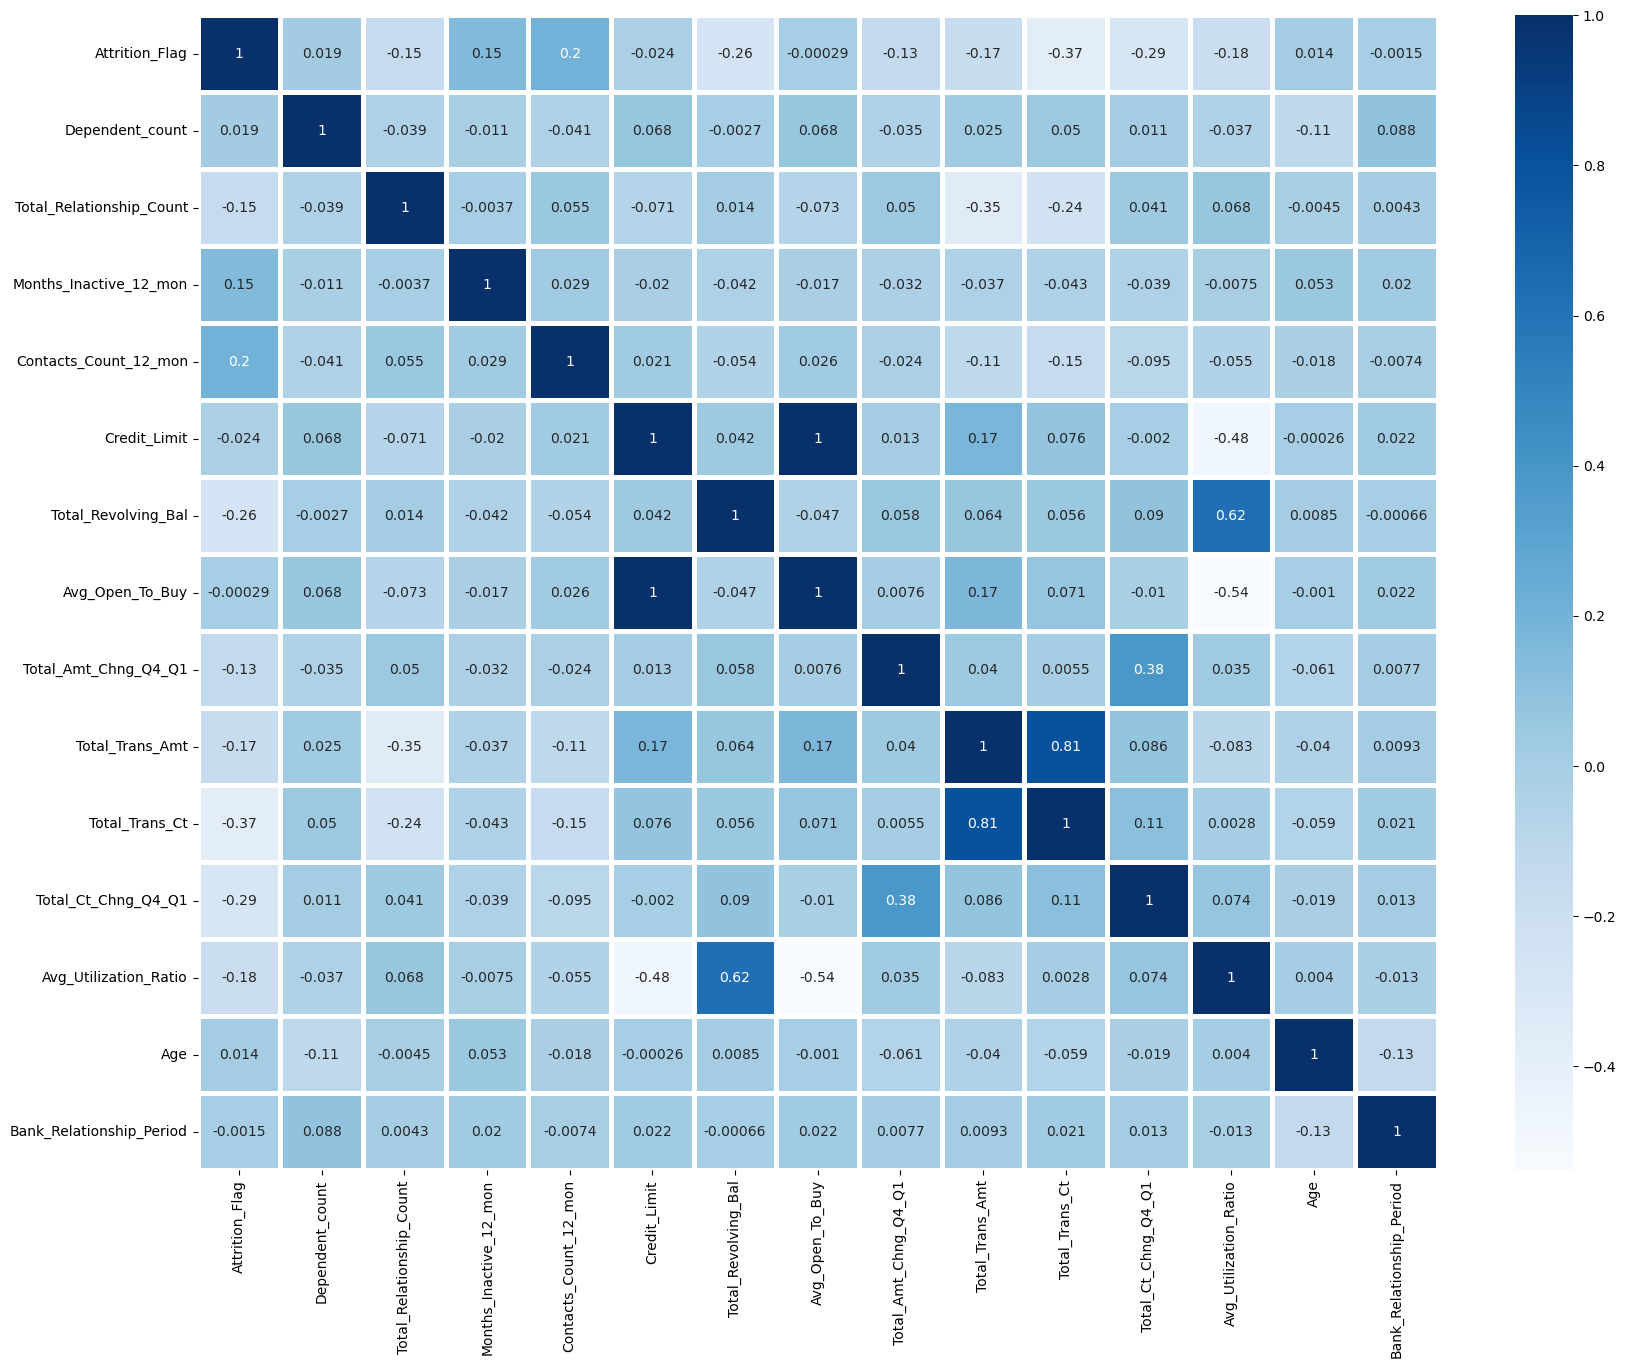

In [39]:
corrmat = df.corr()
top_corr_features = corrmat.index

plt.figure(figsize=(20,15))

#plot heat map
g=sns.heatmap(df[top_corr_features].corr(),annot=True,cmap="Blues",linewidths=3.5,
    linecolor='white')

C:\Users\hp\AppData\Local\Temp\ipykernel_1756\1747921168.py:13: FutureWarning:

The default value of numeric_only in DataFrame.corrwith is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



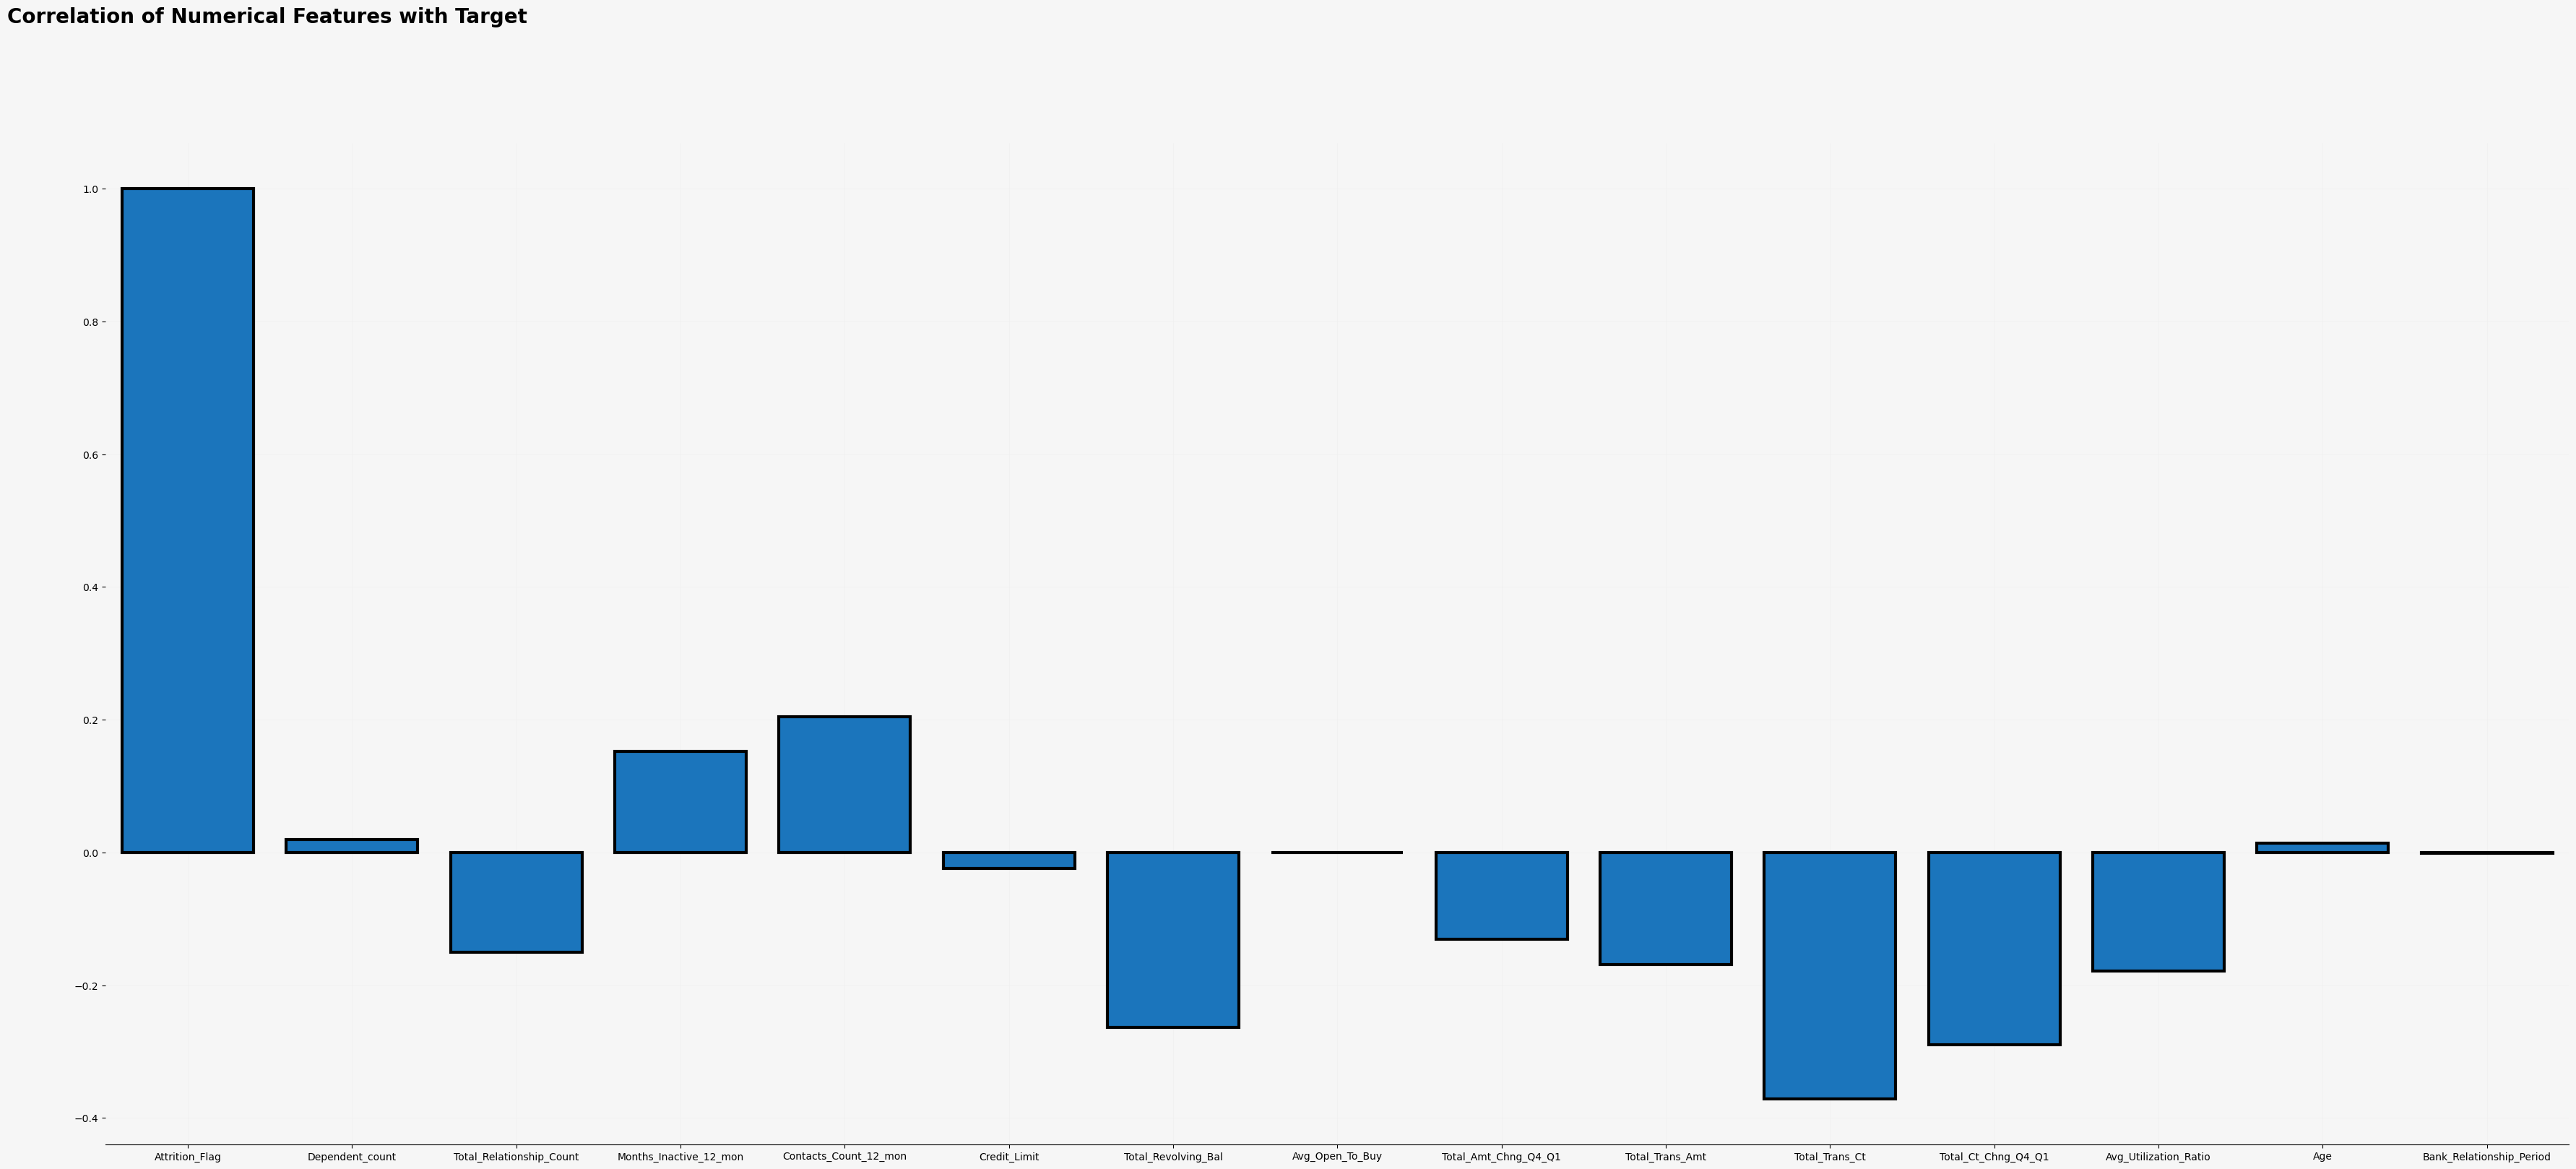

In [40]:
import matplotlib
background_color = "#f6f6f6"

fig = plt.figure(figsize=(44,18), facecolor=background_color)
gs = fig.add_gridspec(1, 1)
ax0 = fig.add_subplot(gs[0, 0])
colors = ["#0078d7"]
colormap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)

ax0.set_facecolor(background_color)
ax0.text(-1.1, 1.25, 'Correlation of Numerical Features with Target', fontsize=20, fontweight='bold')

chart_df = pd.DataFrame(df.corrwith(df['Attrition_Flag']))
chart_df.columns = ['corr']
sns.barplot(x=chart_df.index, y=chart_df['corr'], ax=ax0, color='#0078d7', zorder=3, edgecolor='black', linewidth=3)
ax0.grid(which='major', axis='x', zorder=0, color='#EEEEEE', linewidth=0.4)
ax0.grid(which='major', axis='y', zorder=0, color='#EEEEEE', linewidth=0.4)
ax0.set_ylabel('')

for s in ["top","right", 'left']:
    ax0.spines[s].set_visible(False)

plt.show()

In [41]:
#Now one hot encoding
#df_new=pd.get_dummies(df, columns=['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category'],drop_first=False)

In [58]:
#df_new

In [43]:
#Rearrangement of the columns......
'''df = df_new[[ 'Dependent_count', 'Total_Relationship_Count',
       'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
       'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',
       'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
       'Avg_Utilization_Ratio', 'Age', 'Bank_Relationship_Period', 'Gender_F',
       'Gender_M', 'Education_Level_College', 'Education_Level_Doctorate',
       'Education_Level_Graduate', 'Education_Level_High School',
       'Education_Level_Post-Graduate', 'Education_Level_Uneducated',
       'Education_Level_Unknown', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Unknown', 'Income_Category_$120K +',
       'Income_Category_$40K - $60K', 'Income_Category_$60K - $80K',
       'Income_Category_$80K - $120K', 'Income_Category_Less than $40K',
       'Income_Category_Unknown', 'Card_Category_Blue', 'Card_Category_Gold',
       'Card_Category_Platinum', 'Card_Category_Silver','Attrition_Flag']]'''

"df = df_new[[ 'Dependent_count', 'Total_Relationship_Count',\n       'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',\n       'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',\n       'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',\n       'Avg_Utilization_Ratio', 'Age', 'Bank_Relationship_Period', 'Gender_F',\n       'Gender_M', 'Education_Level_College', 'Education_Level_Doctorate',\n       'Education_Level_Graduate', 'Education_Level_High School',\n       'Education_Level_Post-Graduate', 'Education_Level_Uneducated',\n       'Education_Level_Unknown', 'Marital_Status_Divorced',\n       'Marital_Status_Married', 'Marital_Status_Single',\n       'Marital_Status_Unknown', 'Income_Category_$120K +',\n       'Income_Category_$40K - $60K', 'Income_Category_$60K - $80K',\n       'Income_Category_$80K - $120K', 'Income_Category_Less than $40K',\n       'Income_Category_Unknown', 'Card_Category_Blue', 'Card_Category_Gold',\n       'Card_Category

In [44]:
df

,Attrition_Flag,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Age,Bank_Relationship_Period
0,0,M,3,High School,Married,$60K - $80K,Blue,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,1,3
1,0,F,5,Graduate,Single,Less than $40K,Blue,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,2,0
2,0,M,3,Graduate,Married,$80K - $120K,Blue,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,2,3
3,0,F,4,High School,Unknown,Less than $40K,Blue,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,1,3
4,0,M,3,Uneducated,Married,$60K - $80K,Blue,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,0,M,2,Graduate,Single,$40K - $60K,Blue,3,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,2,3
10123,1,M,2,Unknown,Divorced,$40K - $60K,Blue,4,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,1,2
10124,1,F,1,High School,Married,Less than $40K,Blue,5,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,1,3
10125,1,M,2,Graduate,Unknown,$40K - $60K,Blue,4,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0,3


In [45]:
## To features and target
X = df.drop(columns=['Attrition_Flag'], axis=1)
y = df['Attrition_Flag']

In [48]:
df

,Attrition_Flag,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Age,Bank_Relationship_Period
0,0,M,3,High School,Married,$60K - $80K,Blue,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,1,3
1,0,F,5,Graduate,Single,Less than $40K,Blue,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,2,0
2,0,M,3,Graduate,Married,$80K - $120K,Blue,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,2,3
3,0,F,4,High School,Unknown,Less than $40K,Blue,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,1,3
4,0,M,3,Uneducated,Married,$60K - $80K,Blue,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,0,M,2,Graduate,Single,$40K - $60K,Blue,3,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,2,3
10123,1,M,2,Unknown,Divorced,$40K - $60K,Blue,4,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,1,2
10124,1,F,1,High School,Married,Less than $40K,Blue,5,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,1,3
10125,1,M,2,Graduate,Unknown,$40K - $60K,Blue,4,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0,3


In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.30,random_state = 41)

In [49]:
## --------------------- Data Processing ---------------------------- ##

## Slice the lists
num_cols = [
    "Credit_Limit",
    "Total_Revolving_Bal",
    "Total_Amt_Chng_Q4_Q1",
    "Total_Trans_Amt",
    "Total_Trans_Ct",
    "Total_Ct_Chng_Q4_Q1",
    "Avg_Utilization_Ratio",
]
categ_cols = [
    "Education_Level",
    "Income_Category",
    "Marital_Status",
    "Card_Category",
    "Gender",
]

ready_cols = list(set(X_train.columns.tolist()) - set(num_cols) - set(categ_cols))


## For Numerical
num_pipeline = Pipeline(
    steps=[
        ("selector", DataFrameSelector(num_cols)),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)


## For Categorical
categ_pipeline = Pipeline(
    steps=[
        ("selector", DataFrameSelector(categ_cols)),
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(drop="first", sparse_output=False)),
    ]
)


## For ready cols
ready_pipeline = Pipeline(
    steps=[
        ("selector", DataFrameSelector(ready_cols)),
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)


## combine all
all_pipeline = FeatureUnion(
    transformer_list=[
        ("numerical", num_pipeline),
        ("categorical", categ_pipeline),
        ("ready", ready_pipeline),
    ]
)

## apply
X_train_final = all_pipeline.fit_transform(X_train)
X_test_final = all_pipeline.transform(X_test)

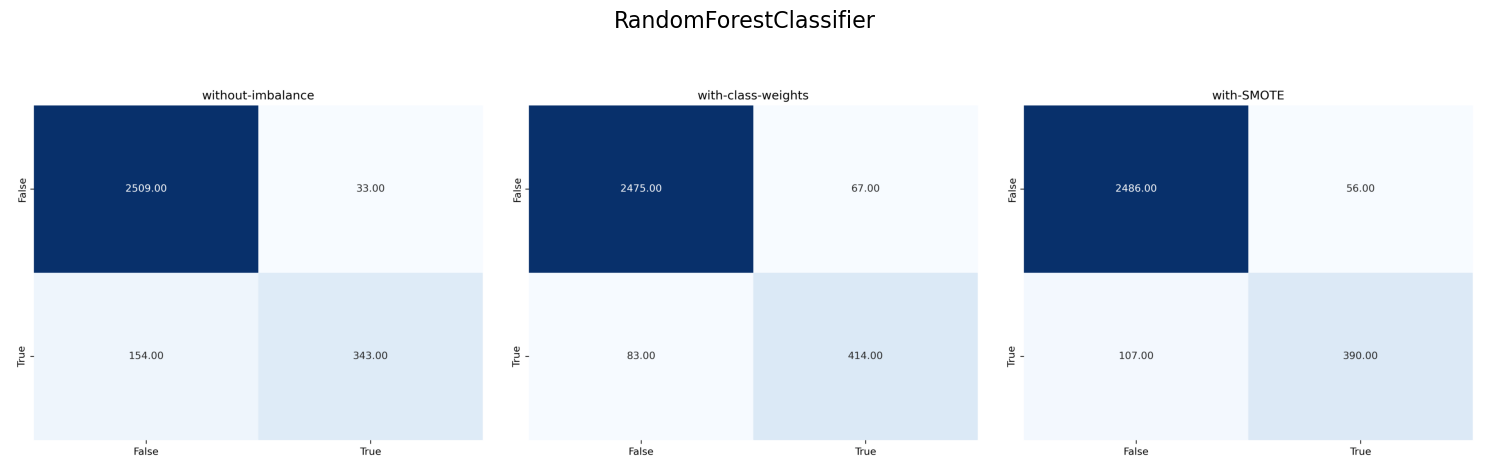

In [57]:
## --------------------- Impalancing ---------------------------- ##

## 1. use algorithm without taking the effect of imbalancing

## 2. prepare class_weights for solving imbalance dataset
vals_count = 1 - (np.bincount(y_train) / len(y_train))
vals_count = vals_count / np.sum(vals_count)  ## normalizing


dict_weights = {}
for i in range(2):  ## 2 classes (0, 1)
    dict_weights[i] = vals_count[i]

## 3. Using SMOTE for over sampling
over = SMOTE(sampling_strategy=0.7)
X_train_resmapled, y_train_resampled = over.fit_resample(X_train_final, y_train)


## --------------------- Modeling ---------------------------- ##

## Clear metrics.txt file at the beginning
with open('metrics.txt', 'w') as f:
    pass


def train_model(X_train, y_train, plot_name='', class_weight=None):
    """ A function to train model given the required train data """
    
    global clf_name

    clf = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=45, class_weight=class_weight)
    clf.fit(X_train, y_train)
    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test_final)
    
    ## Using f1_score
    score_train = f1_score(y_train, y_pred_train)
    score_test = f1_score(y_test, y_pred_test)
    
    clf_name = clf.__class__.__name__

    ## Plot the confusion matrix 
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, cbar=False, fmt='.2f', cmap='Blues')
    plt.title(f'{plot_name}')
    plt.xticks(ticks=np.arange(2) + 0.5, labels=[False, True])
    plt.yticks(ticks=np.arange(2) + 0.5, labels=[False, True])

    ## Save the plot locally
    plt.savefig(f'{plot_name}.png', bbox_inches='tight', dpi=300)
    plt.close()


    ## Write scores to a file
    with open('metrics.txt', 'a') as f:
            f.write(f'{clf_name} {plot_name}\n')
            f.write(f"F1-score of Training is: {score_train*100:.2f} %\n")
            f.write(f"F1-Score of Validation is: {score_test*100:.2f} %\n")
            f.write('----'*10 + '\n')


    return True


## 1. without considering the imabalancing data
train_model(X_train=X_train_final, y_train=y_train, plot_name='without-imbalance', class_weight=None)

## 2. with considering the imabalancing data using class_weights
train_model(X_train=X_train_final, y_train=y_train, plot_name='with-class-weights', class_weight=dict_weights)

## 3. with considering the imabalancing data using oversampled data (SMOTE)
train_model(X_train=X_train_resmapled, y_train=y_train_resampled, plot_name=f'with-SMOTE', class_weight=None)



## Combine all conf matrix in one
confusion_matrix_paths = [f'./without-imbalance.png', f'./with-class-weights.png', f'./with-SMOTE.png']

## Load and plot each confusion matrix
plt.figure(figsize=(15, 5))  # Adjust figure size as needed
for i, path in enumerate(confusion_matrix_paths, 1):
    img = Image.open(path)
    plt.subplot(1, len(confusion_matrix_paths), i)
    plt.imshow(img)
    plt.axis('off')  # Disable axis for cleaner visualization


## Save combined plot locally
plt.suptitle(clf_name, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(f'conf_matrix.png', bbox_inches='tight', dpi=300)

## Delete old image files
for path in confusion_matrix_paths:
    os.remove(path)